In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
import numpy as np
import seaborn as sns
from scipy import stats

!pip install plotly


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Chargement des données

In [43]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CSV_URL = (
    "https://raw.githubusercontent.com/OpenExoplanetCatalogue/"
    "oec_tables/master/comma_separated/open_exoplanet_catalogue.txt"
)

df = pd.read_csv(CSV_URL, comment='#')

# On renomme les colonnes pour la lisibilité
COLS = [
    "name", "binary_flag", "mass", "radius", "period", "semi_major_axis",
    "eccentricity", "periastron", "longitude", "ascending_node",
    "inclination", "surface_temp", "age", "discovery_method",
    "discovery_year", "last_updated", "ra_string", "dec_string",
    "distance_pc", "host_star_mass", "host_star_radius",
    "host_star_metallicity", "host_star_temp", "host_star_age",
    "list_flag"
]

df.columns = COLS[:len(df.columns)]

df.isnull().sum().sort_values(ascending=False)

print(f"Nombre de planètes chargées : {len(df)}")
print(f"\nColonnes disponibles :\n{df.dtypes}")

Nombre de planètes chargées : 5414

Colonnes disponibles :
name                      object
binary_flag                int64
mass                     float64
radius                   float64
period                   float64
semi_major_axis          float64
eccentricity             float64
periastron               float64
longitude                float64
ascending_node           float64
inclination              float64
surface_temp             float64
age                      float64
discovery_method          object
discovery_year           float64
last_updated              object
ra_string                 object
dec_string                object
distance_pc              float64
host_star_mass           float64
host_star_radius         float64
host_star_metallicity    float64
host_star_temp           float64
host_star_age            float64
list_flag                 object
dtype: object


In [44]:
df = df[
    (df['mass'] > 0) &
    (df['host_star_mass'] > 0)
]

In [5]:
print(df.shape)

df.head()

(2634, 25)
Index(['name', 'binary_flag', 'mass', 'radius', 'period', 'semi_major_axis',
       'eccentricity', 'periastron', 'longitude', 'ascending_node',
       'inclination', 'surface_temp', 'age', 'discovery_method',
       'discovery_year', 'last_updated', 'ra_string', 'dec_string',
       'distance_pc', 'host_star_mass', 'host_star_radius',
       'host_star_metallicity', 'host_star_temp', 'host_star_age',
       'list_flag'],
      dtype='object')


,name,binary_flag,mass,radius,period,semi_major_axis,eccentricity,periastron,longitude,ascending_node,...,last_updated,ra_string,dec_string,distance_pc,host_star_mass,host_star_radius,host_star_metallicity,host_star_temp,host_star_age,list_flag
1,HD 154857 b,0,2.24000,NaN,408.60000,1.291,0.46,57.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
2,HD 154857 c,0,2.58000,NaN,3452.00000,5.360,0.06,352.0,NaN,NaN,...,14/01/25,17 11 15.7217,-56 40 50.8706,64.200,1.718,2.310,-0.31,5508.0,NaN,Confirmed planets
7,KMT-2019-BLG-1339L b,0,1.25000,NaN,NaN,2.150,NaN,NaN,NaN,NaN,...,20/09/03,17 42 58,-25 34 26,6120.000,0.480,NaN,NaN,NaN,NaN,Confirmed planets
8,KMT-2019-BLG-1715 b,0,2.56000,NaN,NaN,3.320,NaN,NaN,NaN,NaN,...,21/04/02,18 01 29.00,-28 46 38.00,3860.000,0.760,NaN,NaN,NaN,NaN,Confirmed planets
9,TOI-1685 b,0,0.01189,0.152,0.66914,NaN,NaN,NaN,NaN,NaN,...,21/03/03,04 34 23.00,+43 02 13.00,37.609,0.495,0.492,-0.13,3434.0,NaN,Confirmed planets


In [45]:
missing = df.isnull().sum()

missing.sort_values(ascending=False)

age                      2633
longitude                2592
ascending_node           2588
host_star_age            2140
periastron               1705
inclination              1360
surface_temp             1297
radius                   1129
eccentricity              687
host_star_metallicity     503
host_star_radius          468
semi_major_axis           334
host_star_temp            322
period                    253
distance_pc                34
ra_string                   9
dec_string                  9
discovery_method            9
discovery_year              8
last_updated                3
name                        0
mass                        0
binary_flag                 0
host_star_mass              0
list_flag                   0
dtype: int64

In [8]:
df.describe()

,binary_flag,mass,radius,period,semi_major_axis,eccentricity,periastron,longitude,ascending_node,inclination,surface_temp,age,discovery_year,distance_pc,host_star_mass,host_star_radius,host_star_metallicity,host_star_temp,host_star_age
count,2634.000000,2634.000000,1505.000000,2.381000e+03,2300.000000,1947.000000,929.000000,42.000000,46.000000,1274.000000,1337.000000,1.0000,2626.000000,2600.000000,2634.000000,2166.000000,2131.000000,2312.000000,494.000000
mean,0.118451,2.124582,0.719350,4.309770e+03,8.446810,0.145421,133.806572,158.416349,88.165156,84.344809,952.924020,0.0055,2015.459634,679.646527,0.957619,2.086898,0.033874,5320.847491,4.852462
std,0.472182,6.857034,0.545634,1.648472e+05,168.704274,0.186049,118.562759,130.434680,86.917816,18.294876,613.816835,NaN,8.401275,1532.348235,0.451678,5.020811,0.288195,1308.088013,4.722504
min,0.000000,0.000008,0.016438,9.070629e-02,0.004420,-0.129287,-233.000000,-174.640000,-5.112604,-0.000543,96.400000,0.0055,1781.000000,1.295000,0.010000,0.000014,-2.090000,58.370000,0.002000
25%,0.000000,0.028300,0.207000,4.007232e+00,0.049900,0.000000,50.873000,45.375000,4.820000,85.355000,486.900000,0.0055,2011.000000,45.562100,0.750000,0.790000,-0.090000,4843.250000,2.192500
50%,0.000000,0.465000,0.616000,1.322260e+01,0.130900,0.077000,124.000000,183.089854,67.340000,88.000000,867.000000,0.0055,2017.000000,149.585000,0.960500,1.040500,0.051000,5513.000000,4.200000
75%,0.000000,1.920000,1.169000,2.689400e+02,1.320000,0.210000,220.860000,258.400000,148.932500,89.230000,1333.000000,0.0055,2021.000000,490.825000,1.145520,1.481750,0.190000,5900.000000,6.775000
max,2.000000,263.000000,6.000000,8.040000e+06,6471.000000,0.956000,791.000000,339.300000,320.800000,177.300000,7112.000000,0.0055,2023.000000,8500.000000,9.100000,86.400000,7.790000,29300.000000,80.000000


# Acte I : Exploration visuelle

Avant de chercher des structures cachées ou des biais, prenons d'abord le temps d'observer ce que le catalogue nous dit à l'œil nu.

# Masse vs Rayon

C:\Users\Nbayo\AppData\Local\Temp\ipykernel_16000\3981748070.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


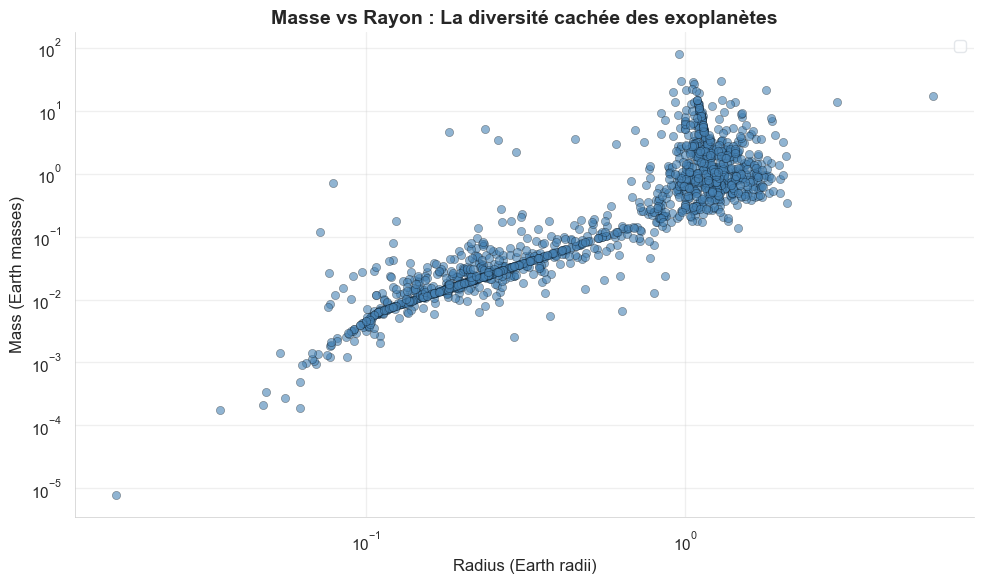

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy import stats

sns.scatterplot(
    data=df,
    x="radius",
    y="mass",
    alpha=0.6,
    s=35,
    color='steelblue',
    edgecolors='black',
    linewidth=0.3
)

# Régression linéaire sur les logs
df_clean = df.dropna(subset=["radius", "mass"])
df_clean = df_clean[(df_clean["radius"] > 0) & (df_clean["mass"] > 0)]

x_log = np.log10(df_clean["radius"])
y_log = np.log10(df_clean["mass"])

slope, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Radius (Jupiter radii)", fontsize=12)
plt.ylabel("Mass (Jupiter masses)", fontsize=12)
plt.title("Masse vs Rayon : La diversité cachée des exoplanètes", fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

plt.tight_layout()
plt.show()

La masse et le rayon des exoplanètes sont très corrélés. Ce graphique nous révèle une tendance claire. Plus une planète est massive, plus elle est grande. Mais la relation n'est pas linéaire. Elle suit une loi de puissance.

Si on regarde plus attentivement, les points ne se répartissent pas au hasard. On devine déjà plusieurs groupes : des planètes petites et denses (en bas à gauche), des planètes géantes (en haut à droite), et des objets intermédiaires. C'est cette intuition que nous formaliserons plus tard avec le clustering.

# La troisième loi de Kepler

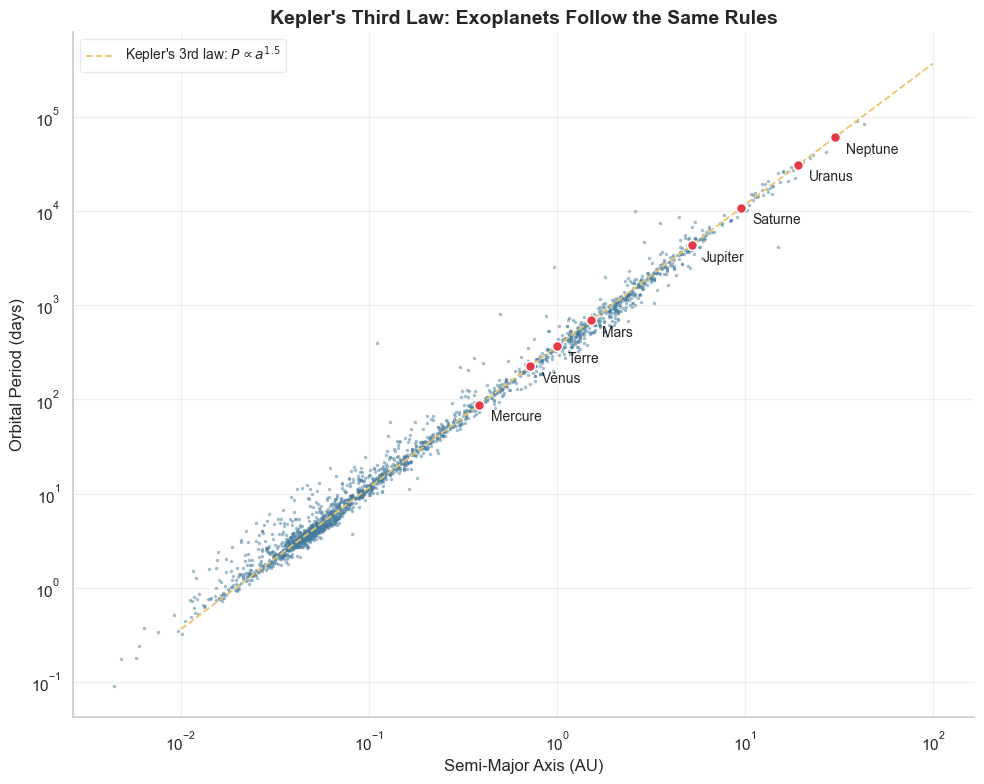

In [47]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

if 'period' in df.columns and 'semi_major_axis' in df.columns:
    sub = df.dropna(subset=['period', 'semi_major_axis'])
    sub = sub[(sub['period'] > 0) & (sub['semi_major_axis'] > 0)]
    sub = sub[sub['period'] < 100000]

    plt.scatter(sub['semi_major_axis'], sub['period'],
                s=6, alpha=0.5, color='#457B9D', linewidths=0)

    # Loi de Kepler
    a_ref = np.logspace(-2, 2, 200)
    plt.plot(a_ref, 365.25 * a_ref**1.5, color='#E9C46A',
             lw=1.3, ls='--', label='Kepler\'s 3rd law: $P \\propto a^{1.5}$')

    # Planètes du Système Solaire
    solar_system = [
        ('Mercure', 0.387, 88),
        ('Vénus', 0.723, 225),
        ('Terre', 1.0, 365),
        ('Mars', 1.524, 687),
        ('Jupiter', 5.203, 4333),
        ('Saturne', 9.537, 10759),
        ('Uranus', 19.191, 30687),
        ('Neptune', 30.069, 60190)
    ]

    for name, a, p in solar_system:
        plt.scatter(a, p, s=50, color='#E63946', edgecolor='white', linewidth=1, zorder=5)
        plt.annotate(name, (a, p), fontsize=10, color='black', alpha=0.85,
                     xytext=(8, -4), textcoords='offset points', ha='left', va='top')

    plt.xscale('log')
    plt.yscale('log')

    plt.xlabel("Semi-Major Axis (AU)", fontsize=12)
    plt.ylabel("Orbital Period (days)", fontsize=12)
    plt.title("Troisième loi de Kepler : Les exoplanètes suivent les mêmes règles", fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

else:
    print(" Colonnes 'period' ou 'semi_major_axis' absentes")

plt.tight_layout()
plt.show()

Autre relation fondamentale : la période orbitale augmente avec la distance à l'étoile. La troisieme loi de kepler stipule que le carré de la période orbitale d'une planète est proportionnel au cube du demi-grand axe de son orbite. En appliquant une transformation logarithmique, on obtient une ligne droite. C'est exactement ce que l'on observe. Les exoplanètes suivent parfaitement cette loi, tout comme les planètes du Système Solaire. La physique est la même partout dans l'Univers.

## Température vs masse solaire

Températures : min=58K, max=8500K


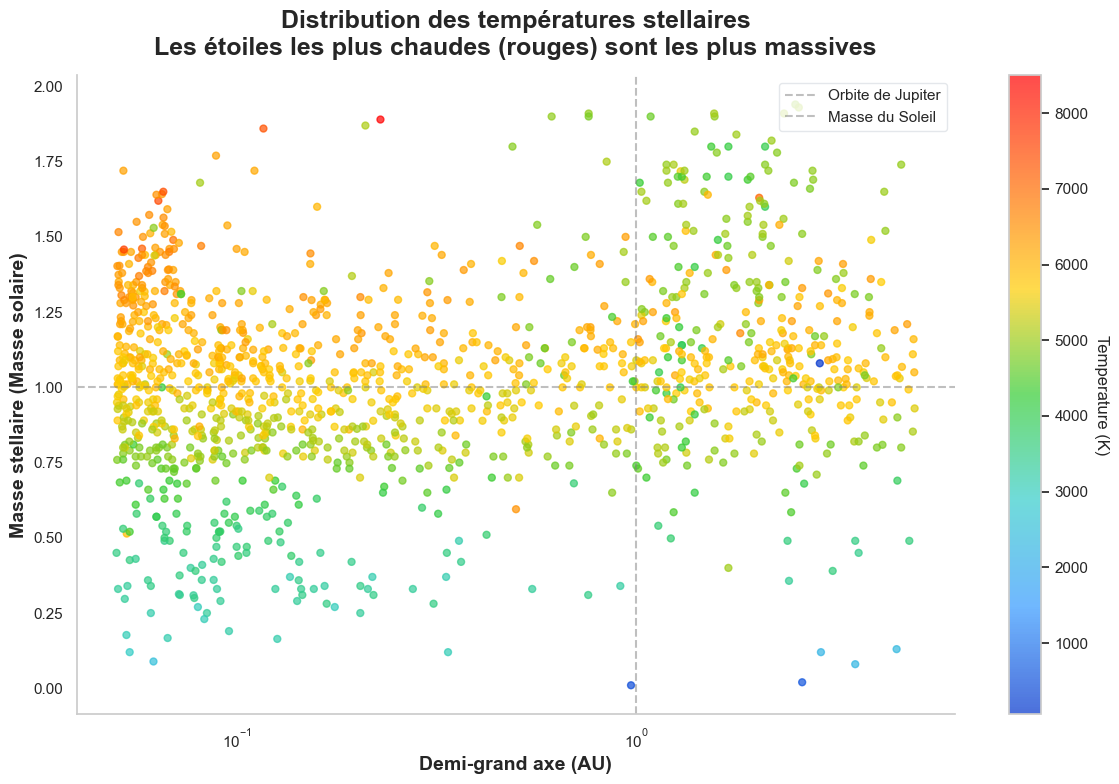

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

plt.figure(figsize=(12,8))

df_hz = df[
    (df["semi_major_axis"] < 5) &
    (df["host_star_mass"] < 2) &
    (df["semi_major_axis"] > 0.05) &
    (df["host_star_temp"] < 15000)
]

t_min = df_hz["host_star_temp"].min()
t_max = df_hz["host_star_temp"].max()

print(f"Températures : min={t_min:.0f}K, max={t_max:.0f}K")

progressive_cmap = LinearSegmentedColormap.from_list(
    "progressive_temp",
    [
        "#0033cc",   # bleu foncé
        "#3399ff",   # bleu clair
        "#33cccc",   # cyan
        "#33cc33",   # vert
        "#ffcc00",   # jaune
        "#ff6600",   # orange
        "#ff0000"    # rouge
    ]
)

sc = plt.scatter(
    df_hz["semi_major_axis"],
    df_hz["host_star_mass"],
    c=df_hz["host_star_temp"],
    cmap=progressive_cmap,
    alpha=0.7,
    s=25
)

cbar = plt.colorbar(sc, label="Température stellaire (K)")
cbar.ax.set_ylabel("Temperature (K)", rotation=270, labelpad=15)

plt.xscale("log")
plt.xlabel("Demi-grand axe (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Masse stellaire (Masse solaire)", fontsize=14, fontweight='bold')
plt.title("Distribution des températures stellaires\nLes étoiles les plus chaudes (rouges) sont les plus massives",
          fontsize=18, fontweight='bold', pad=15)

plt.axvline(x=1, linestyle="--", color="gray", alpha=0.5, linewidth=1.5, label="Orbite de Jupiter")
plt.axhline(y=1, linestyle="--", color="gray", alpha=0.5, linewidth=1.5, label="Masse du Soleil")

plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(loc="upper right", fontsize=11)
plt.tight_layout()
plt.show()

Les étoiles les plus massives sont aussi les plus chaudes. Cette relation, bien connue en astrophysique, est vérifiée dans notre catalogue. Elle rappelle que les propriétés des planètes sont très liées à celles de leur étoile.

# Distribution des masses stellaires

Mais malgré cette diversité de températures, notre échantillon reste centré sur les étoiles solaires. Un biais à ne pas oublier.

Points bleus (transit): 1327
Points oranges (RV): 1009
Points gris (autres): 298


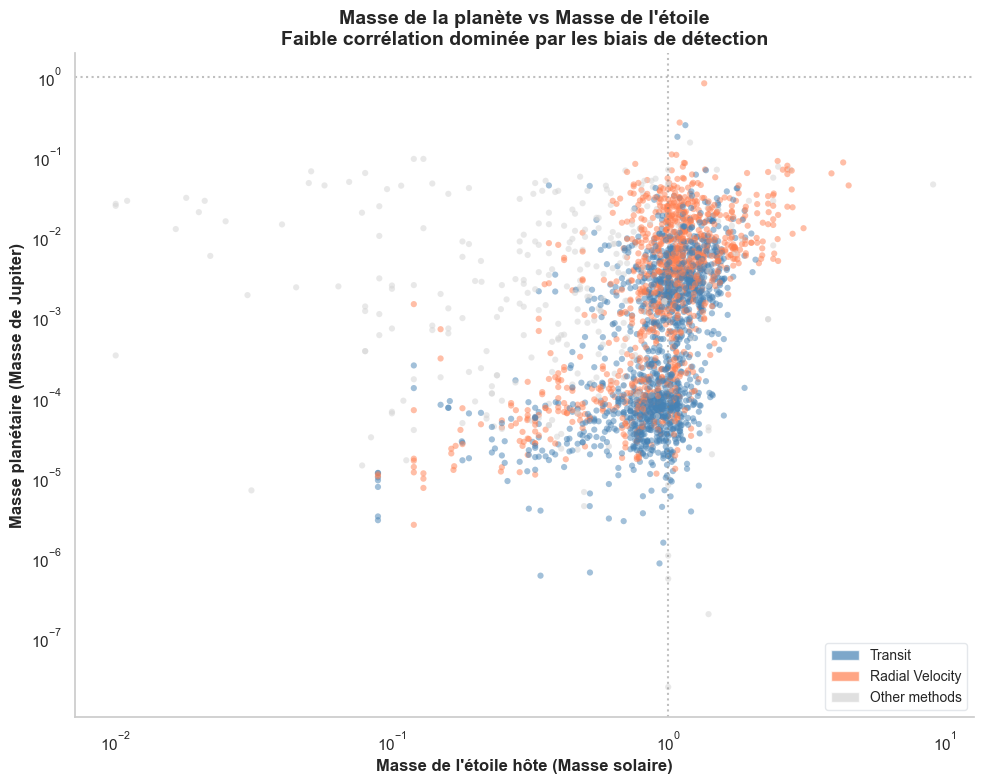

In [61]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# on filtre les données
mask = df['mass'].notna() & df['host_star_mass'].notna() & (df['mass'] > 0) & (df['host_star_mass'] > 0)
sub = df[mask]

# Convertir en masses de Jupiter
sub['mass_jupiter'] = sub['mass'] / 318

# Fonction de couleur robuste
def get_color(method):
    if method is None:
        return 'lightgray'
    method_str = str(method).lower()
    if 'transit' in method_str:
        return 'steelblue'
    elif 'radial' in method_str or method_str == 'rv':
        return 'coral'
    else:
        return 'lightgray'

colors = sub['discovery_method'].map(get_color)

# Compter pour vérifier
print(f"Points bleus (transit): {sum(c == 'steelblue' for c in colors)}")
print(f"Points oranges (RV): {sum(c == 'coral' for c in colors)}")
print(f"Points gris (autres): {sum(c == 'lightgray' for c in colors)}")

plt.figure(figsize=(10, 8))

plt.scatter(sub['host_star_mass'], sub['mass_jupiter'], c=colors, alpha=0.5, s=20, edgecolors='none')

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Masse de l'étoile hôte (Masse solaire)", fontsize=12, fontweight='bold')
plt.ylabel("Masse planétaire (Masse de Jupiter)", fontsize=12, fontweight='bold')
plt.title("Masse de la planète vs Masse de l'étoile\nFaible corrélation dominée par les biais de détection",
          fontsize=14, fontweight='bold')

plt.axhline(y=1, linestyle=':', color='gray', alpha=0.5, label='Masse de Jupiter')
plt.axvline(x=1, linestyle=':', color='gray', alpha=0.5, label='Masse du Soleil')

legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Transit'),
    Patch(facecolor='coral', alpha=0.7, label='Radial Velocity'),
    Patch(facecolor='lightgray', alpha=0.7, label='Other methods')
]

plt.legend(handles=legend_elements, loc='lower right', fontsize=10)
plt.grid(False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

On remarque que la distribution des masses stellaires dans notre échantillon montre un pic autour d'une masse solaire. C'est pas un reflet de la réalité astrophysique (du genre les naines sont bien plus nombreuses dans la galaxie), mais c'est plutot un biais observationnel parce que les télescopes et les méthodes de détection ont été optimisés pour les étoiles de type solaire.

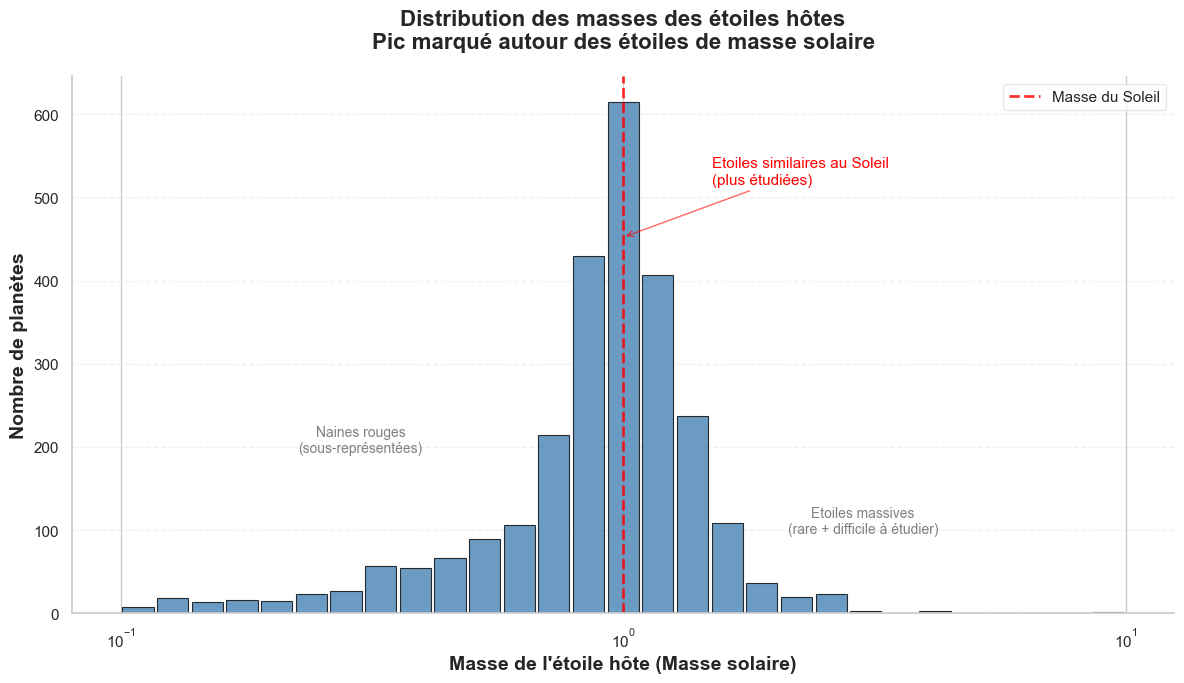

In [63]:
star_masses = df['host_star_mass'].dropna()
star_masses = star_masses[(star_masses > 0) & (star_masses < 10)]  # on enleve les extrêmes

plt.figure(figsize=(12, 7))

# Bins logarithmiques
bins_log = np.logspace(np.log10(0.1), np.log10(10), 30)

plt.hist(star_masses, bins=bins_log, color='steelblue', alpha=0.8,
         edgecolor='black', linewidth=0.8, rwidth=0.9)

plt.xscale('log')
plt.xlabel("Masse de l'étoile hôte (Masse solaire)", fontsize=14, fontweight='bold')
plt.ylabel("Nombre de planètes", fontsize=14, fontweight='bold')
plt.title("Distribution des masses des étoiles hôtes\nPic marqué autour des étoiles de masse solaire",
          fontsize=16, fontweight='bold', pad=20)

# Ajouter une ligne verticale pour le Soleil
plt.axvline(x=1, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Masse du Soleil')

# Annotations
plt.annotate('Etoiles similaires au Soleil \n(plus étudiées)', xy=(1, plt.ylim()[1]*0.7),
             xytext=(1.5, plt.ylim()[1]*0.8), fontsize=11, color='red',
             arrowprops=dict(arrowstyle='->', color='red', alpha=0.6))

plt.annotate('Naines rouges\n(sous-représentées)', xy=(0.3, plt.ylim()[1]*0.3),
             fontsize=10, color='gray', ha='center')

plt.annotate('Etoiles massives\n(rare + difficile à étudier)', xy=(3, plt.ylim()[1]*0.15),
             fontsize=10, color='gray', ha='center')

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=11)

# Supprime les cadres du haut et droite
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Hot Jupiters (masse vs distance)

Parmi toutes les exoplanètes, une famille se distingue : les Hot Jupiters. Ces géantes gazeuses orbitent à moins de 0,1 UA de leur étoile, c'est à dire, vingt fois plus près que la Terre du Soleil. Leurs masses provoquent d'importantes perturbations de leur étoile hote (plus gros effet Doppler).Leur existence défie certaines théories de formation planétaire et illustre la diversité extrême des systèmes exoplanétaires.

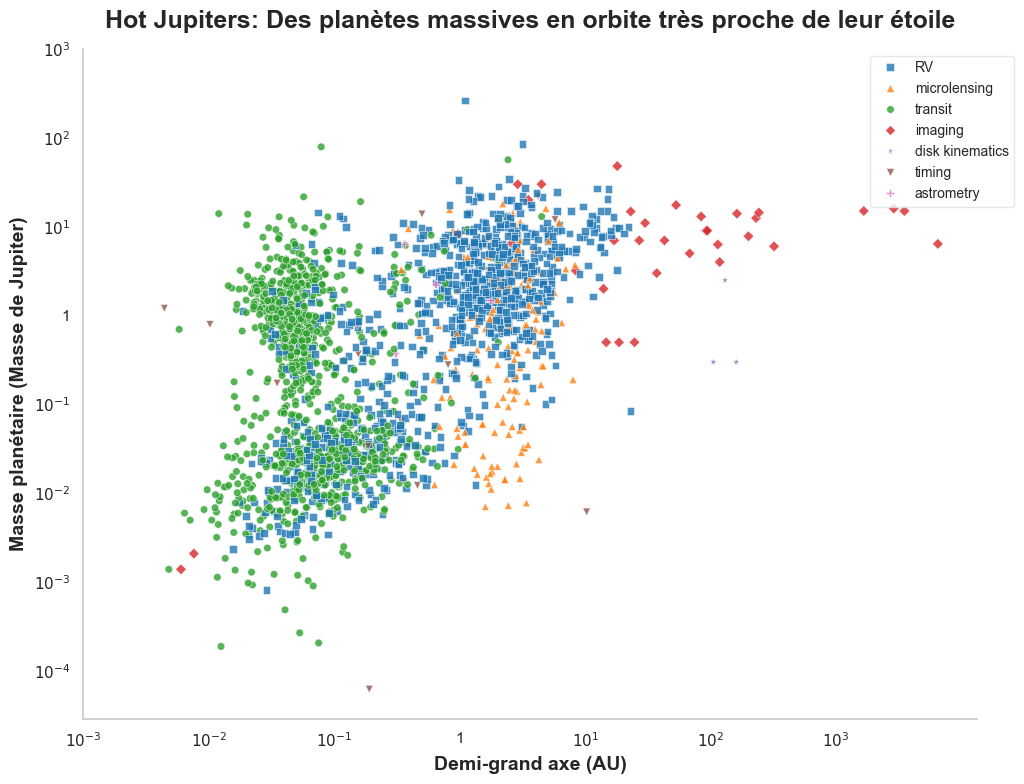

In [64]:
plt.figure(figsize=(12,8))

markers = {
    "transit": "o",
    "rv": "s",
    "RV": "s",
    "disk kinematics": "*",
    "radial velocity": "s",
    "imaging": "D",
    "microlensing": "^",
    "timing": "v",
    "astrometry": "P"
}

# Palette de couleurs
methods = df['discovery_method'].unique()
palette = dict(zip(methods, sns.color_palette("tab10", n_colors=len(methods))))

sns.scatterplot(
    data=df,
    x="semi_major_axis",
    y="mass",
    hue="discovery_method",
    style="discovery_method",
    markers=markers,
    palette=palette,
    alpha=0.8,
    s=30
)

plt.xscale("log")
plt.yscale("log")

ax = plt.gca()

ax.set_xticks([0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_xticklabels([r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

ax.set_yticks([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])
ax.set_yticklabels([r'$10^{-4}$', r'$10^{-3}$', r'$10^{-2}$', r'$10^{-1}$', '1', r'$10^{1}$', r'$10^{2}$', r'$10^{3}$'])

plt.xlabel("Demi-grand axe (AU)", fontsize=14, fontweight='bold')
plt.ylabel("Masse planétaire (Masse de Jupiter)", fontsize=14, fontweight='bold')
plt.title("Hot Jupiters: Des planètes massives en orbite très proche de leur étoile",
          fontsize=18, fontweight='bold', pad=15)

plt.grid(False)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)

plt.legend(bbox_to_anchor=(1.05, 1), fontsize=10)
plt.tight_layout()
plt.show()

Ces observations nous ont donné une première carte du territoire. Mais peut-on aller plus loin et regrouper naturellement les exoplanètes en familles ? C'est ce que nous verrons dans l'Acte II.